# **Normalization and Non-Linear Data Transfromation of Data**

### **What Is Data Transformation?**

Data transformation is the process of applying mathematical functions to data to change its distribution, scale, or structure. This is often done to meet the assumptions required by statistical analyses or to make the data more suitable for modeling and interpretation.

### **Normal Data Transformation**

Normal data transformation refers to techniques used when the data is already approximately normally distributed (bell-shaped curve). In such cases, only minimal or standard transformations are needed, mainly for scaling or centering:

- `Standard Scaling (Z-score normalization):` Centers the data to have a mean of 0 and a standard deviation of 1.
- `Min-Max Scaling`: Rescales features to a fixed range, usually [0,.
- `No Transformation`: If the data is already normal, often no transformation is needed except for scaling.

Purpose:

- To ensure comparability between features.
- To improve the performance of algorithms sensitive to scale.

### **Non-Normal Data Transformation**

Non-normal data transformation involves converting data that does not follow a normal distribution (e.g., skewed, heavy-tailed) into a form that is closer to normal. This is important because many statistical tests and machine learning models assume normality. Common transformation techniques include:

- `Logarithmic Transformation`: Used when data is positively skewed (long right tail). It compresses large values and stretches small values.
- `Square Root Transformation`: Useful for count data or moderate skewness.
- `Reciprocal Transformation`: Used for data with high variability; inverts the values.
- `Box-Cox Transformation`: A family of power transformations that can handle various types of non-normality by finding an optimal exponent (λ) to make the data as normal as possible.
- `Cube Root and Other Power Transformations`: Used depending on the degree and direction of skewness.

Purpose:

- To make the data distribution more symmetric and closer to normal.
- To stabilize variance and make statistical analysis more valid.

In [1]:
## 1. import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 2. generate a non-normal dataset.

np.random.seed(0)                                                # For reproducibility
df=np.random.exponential(size=1000,scale=2)
df = pd.DataFrame(df, columns=['Non_Normal_Column'])
df.head()

,Non_Normal_Column
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


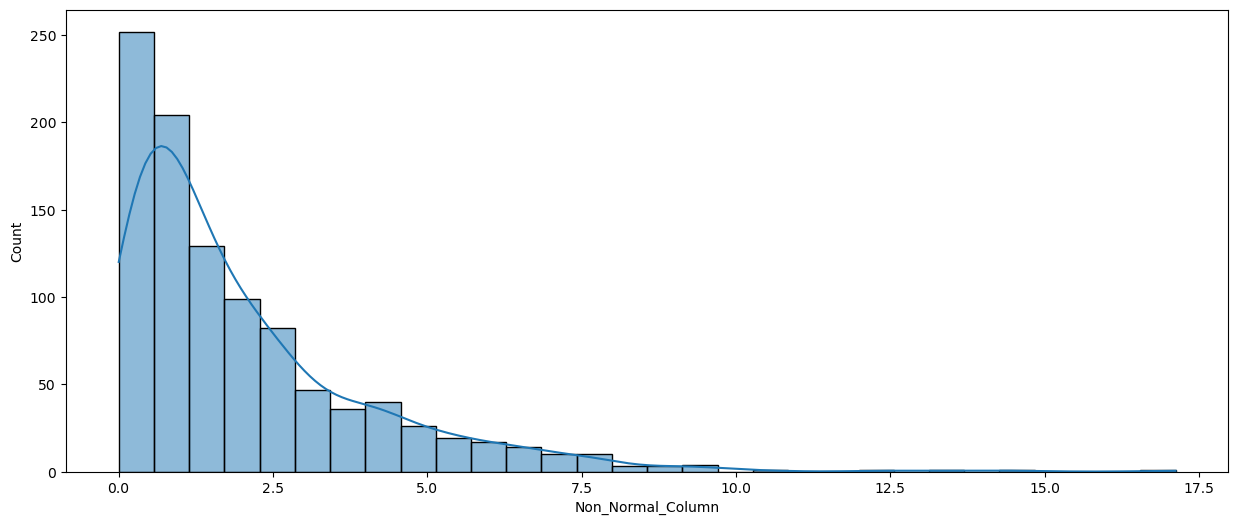

In [4]:
## 3. visualize the dataset contain colomn one by one.
plt.figure(figsize=(15, 6))
sns.histplot(df['Non_Normal_Column'], bins=30, kde=True)
plt.show()

In [5]:
## Transfromation of non normal data using power transformer
from sklearn.preprocessing import PowerTransformer

# Power Transformer
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeol_johnson = PowerTransformer(method='yeo-johnson')

# the first assumption of box-cox is that the data should be positive.
df['df_boxcox'] = pt_boxcox.fit_transform(df[['Non_Normal_Column']]+1)                # Adding 1 to make all values positive
df['df_yeo_johnson'] = pt_yeol_johnson.fit_transform(df[['Non_Normal_Column']])

df.head()

,Non_Normal_Column,df_boxcox,df_yeo_johnson
0,1.591749,0.179335,0.179335
1,2.511862,0.677331,0.677331
2,1.846446,0.339698,0.339698
3,1.574402,0.167607,0.167607
4,1.102097,-0.202107,-0.202107


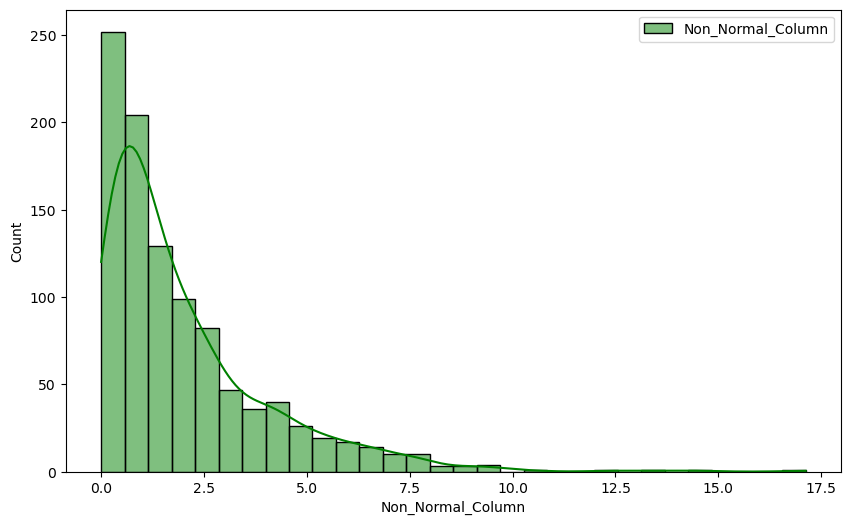

In [25]:
# Visualize the transformed data of all the colomns in the dataframe.
plt.figure(figsize=(10, 6))
sns.histplot(df['Non_Normal_Column'], bins=30, kde=True, color='green', label='Non_Normal_Column')
plt.legend()
plt.show()

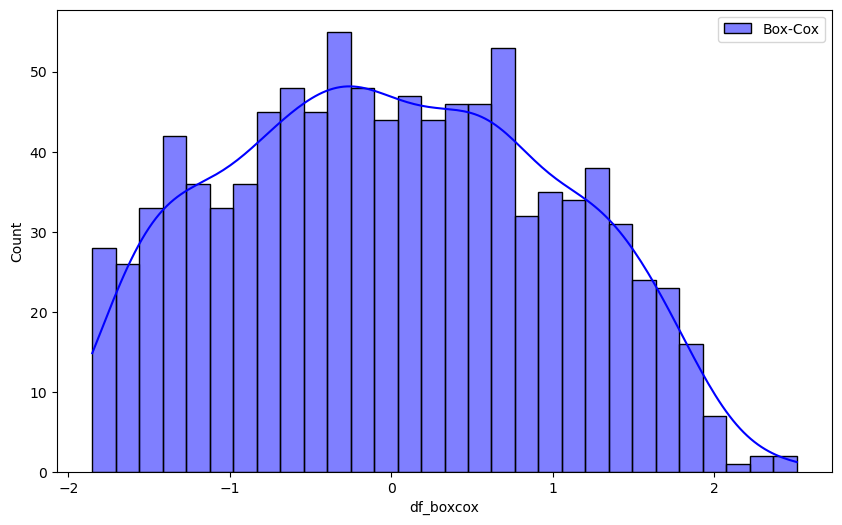

In [26]:
# Visualize the transformed data of all the colomns in the dataframe.
plt.figure(figsize=(10, 6))
sns.histplot(df['df_boxcox'], bins=30, kde=True, color='blue', label='Box-Cox')
plt.legend()
plt.show()

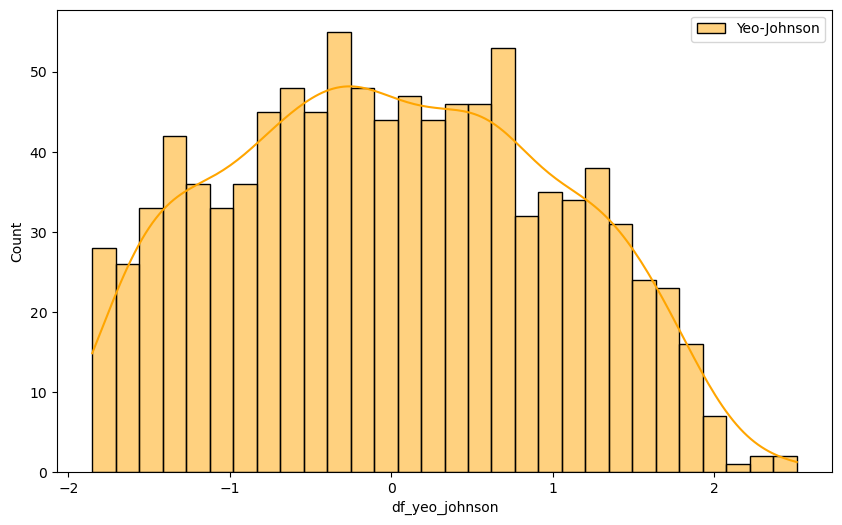

In [27]:
# Visualize the transformed data of all the colomns in the dataframe.
plt.figure(figsize=(10, 6))
sns.histplot(df['df_yeo_johnson'], bins=30, kde=True, color='orange', label='Yeo-Johnson')
plt.legend()
plt.show()

In [6]:
## Transfromation of non normal data using power transformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

# Power Transformer
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeol_johnson = PowerTransformer(method='yeo-johnson')
Quantile_transformer = QuantileTransformer(output_distribution='normal')

# the first assumption of box-cox is that the data should be positive.
df['df_boxcox'] = pt_boxcox.fit_transform(df[['Non_Normal_Column']]+1)                # Adding 1 to make all values positive
df['df_yeo_johnson'] = pt_yeol_johnson.fit_transform(df[['Non_Normal_Column']])
df['df_quantile'] = Quantile_transformer.fit_transform(df[['Non_Normal_Column']])
df.head()

,Non_Normal_Column,df_boxcox,df_yeo_johnson,df_quantile
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677331,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


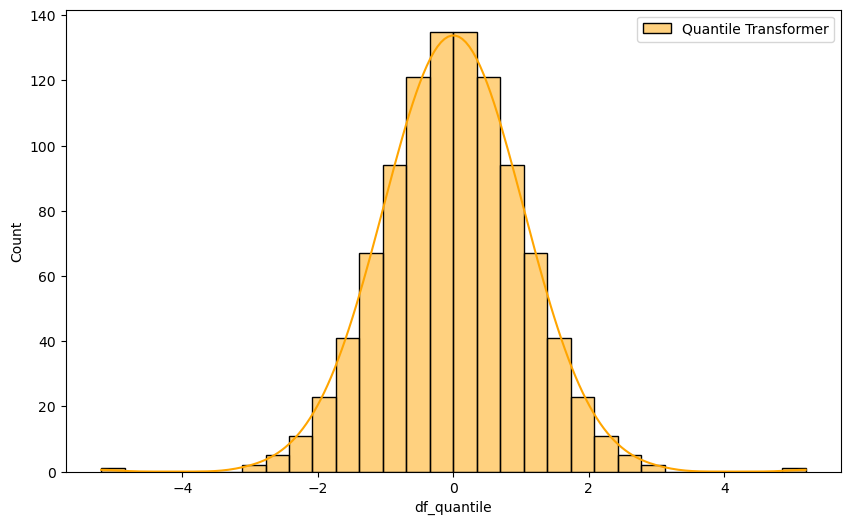

In [7]:
# Visualize the transformed data of all the colomns in the dataframe.
plt.figure(figsize=(10, 6))
sns.histplot(df['df_quantile'], bins=30, kde=True, color='orange', label='Quantile Transformer')
plt.legend()
plt.show()

---

### **L1 and L2 Normalization**

#### **L1 Normalization**

L1 normalization, also known as Least Absolute Deviations or Manhattan norm normalization, transforms a vector so that the sum of the absolute values of its components equals 1.Mathematically, for a vector 

`v = [v 1, v2, ..., vn]`

the L1 norm is:

∥v∥ 1 = |v1| + |v2| + ... + |vn|

The L1-normalized vector is:

v′= v / ∥v∥

**Purpose:**

This normalization is used to scale data while preserving the proportion between components, making the sum of their absolute values 1.

**Application:**

Common in machine learning, especially when dealing with sparse data or when feature selection is important, as L1 regularization can drive some coefficients to zero.

In [9]:
from sklearn.preprocessing import Normalizer

df_1=[[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]]

normalize=Normalizer(norm='l1')  # l2 norm is the default
df_2=normalize.fit_transform(df_1)  
print(df_2)

[[0.16666667 0.33333333 0.5       ]
 [0.26666667 0.33333333 0.4       ]
 [0.29166667 0.33333333 0.375     ]]


#### **L2 Normalization**

L2 normalization, also called Euclidean norm normalization, transforms a vector so that the sum of the squares of its components equals 1.

For a vector 
`v = [v1, v2, ..., vn]`, the L2 norm is:

∥v∥2 = sqrt(v1^2 + v2^2 + ... + vn^2)
 
The L2-normalized vector is:

v′= v / ∥v∥2

**Purpose:**
L2 normalization scales the vector to have a length of 1, preserving direction but not magnitude.

**Application:**
Widely used in machine learning and statistics to ensure features contribute equally, especially when input features have different scales.


In [8]:
from sklearn.preprocessing import Normalizer

df_1=[[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]]

normalize=Normalizer(norm='l2')  # l2 norm is the default
df_2=normalize.fit_transform(df_1)  
print(df_2)

[[0.26726124 0.53452248 0.80178373]
 [0.45584231 0.56980288 0.68376346]
 [0.50257071 0.57436653 0.64616234]]


### **Logrithm Transformation**

In [12]:
## 1. import the necessary libraries
import pandas as pd
import numpy as np

## 2. Create a skewed dataset
df_sk={
    'values' : [1,23,34,45,56,67,78,89,90,100,110,120,130,140,150,160,170,180,190,200]
}
df = pd.DataFrame(df_sk)
df.head()

,values
0,1
1,23
2,34
3,45
4,56


In [13]:
## 3. Apply logarithm transformation
df['log_values'] = np.log(df['values'])
df.head()

,values,log_values
0,1,0.000000
1,23,3.135494
2,34,3.526361
3,45,3.806662
4,56,4.025352


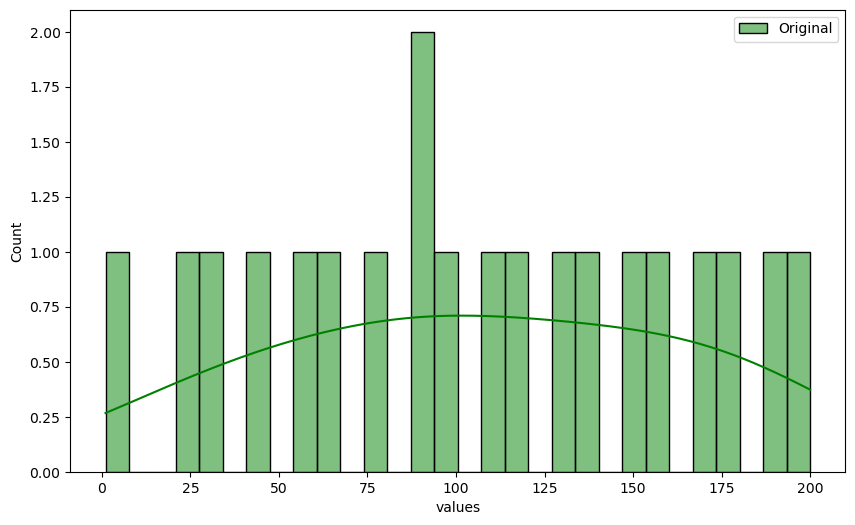

In [14]:
## 4. Visualize the original and transformed data
plt.figure(figsize=(10, 6))
sns.histplot(df['values'], bins=30, kde=True, color='green', label='Original')
plt.legend()
plt.show()

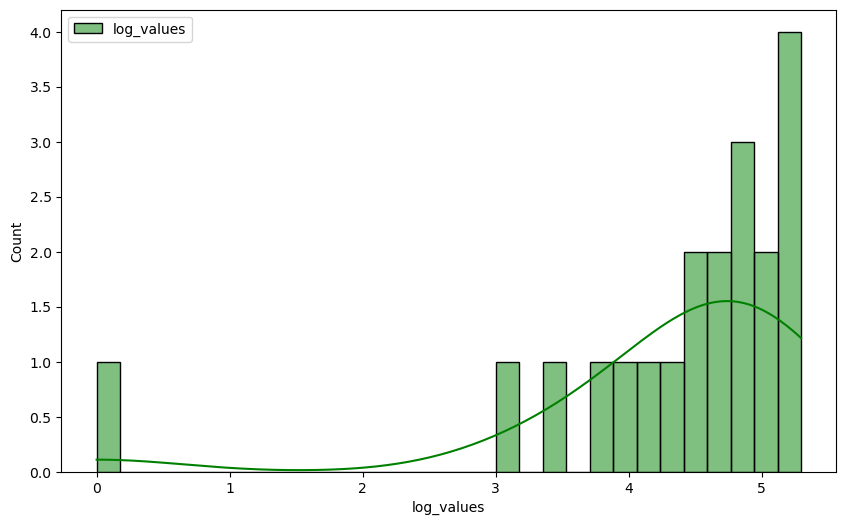

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['log_values'], bins=30, kde=True, color='green', label='log_values')
plt.legend()
plt.show()

## **Feature Scaling VS Normalization**

### **Feature Scaling:**

**Feature scaling** is a data preprocessing technique in machine learning that transforms numerical features in a dataset to a common scale or range. This is crucial because different features often have different units or magnitudes (e.g., age in years vs. income in thousands), and without scaling, models may become biased toward features with larger ranges, leading to poor performance.

#### Why is Feature Scaling Important?

- **Equal contribution:** It ensures all features contribute equally to the model, preventing dominance by features with large values.
- **Improved convergence:** Algorithms using gradient descent (like linear regression, neural networks) converge faster when features are scaled.
- **Distance-based methods:** Algorithms relying on distance calculations (e.g., k-Nearest Neighbors, K-Means clustering, Support Vector Machines) are sensitive to feature scales; scaling prevents skewed distance metrics.
- **Regularization:** Helps in regularization techniques by penalizing coefficients appropriately.

#### Common Methods of Feature Scaling

- **Normalization:** Rescales features to a fixed range, usually 0 to 1, based on minimum and maximum values.
- **Standardization:** Transforms features to have a mean of 0 and a standard deviation of 1 (Z-score normalization).
- **Robust Scaling:** Uses percentiles (like median and interquartile range) to scale data, making it robust to outliers.
- **Min-Max Scaling:** Similar to normalization, scales data to a predefined range, typically.

#### Summary

Feature scaling is essential to prepare data for machine learning, ensuring balanced feature influence, faster and more stable training, and better overall model performance. It is a fundamental step in data preprocessing, especially for algorithms sensitive to feature magnitudes or distances between data points.

### **Normalization**

**Normalization** in machine learning is a specific type of feature scaling that transforms data features to a common, standard range, typically between 0 and 1 or sometimes -1 and 1. This process ensures that all features contribute equally to the learning process by eliminating the bias caused by differing scales or units of measurement across features.

#### Key Points about Normalization

- **Purpose:**  
  Normalization rescales features so that their values lie within a uniform range, preventing features with larger numeric ranges from dominating those with smaller ranges during model training.

- **Why It Matters:**  
  Many machine learning algorithms, especially those relying on distance metrics (e.g., k-Nearest Neighbors, Support Vector Machines) or gradient-based optimization (e.g., neural networks, linear regression), perform better and converge faster when features are normalized.

- **Common Methods:**  
  - **Min-Max Scaling:** Rescales features to a fixed range, usually [0,, using the formula:  

            `Normalized Value = Value - Min / (Max - Min).`
   
    This ensures the minimum feature value maps to 0 and the maximum to 1.
  
  - **Z-score Normalization (Standardization):** Transforms features to have a mean of 0 and standard deviation of 1 by subtracting the mean and dividing by the standard deviation. This centers data around zero and scales variance uniformly.

- **Benefits:**  
  - Improves model accuracy and stability by ensuring balanced feature influence.  
  - Accelerates convergence in training algorithms.  
  - Reduces the risk of features with large scales overpowering others.  
  - Helps in reducing overfitting and improving generalization.

#### Summary

Normalization is a fundamental preprocessing step that rescales numerical features to a standard range, typically [0,, enabling fair contribution of all features during model training. It is especially critical for algorithms sensitive to feature scales and distances, ensuring faster, more stable, and more accurate machine learning models.

### **Key Difference between Normalization and Standard scaling**

`Normalization` is a specific feature scaling technique that rescales data to a fixed range, usually between 0 and 1, based on the minimum and maximum values of the feature. `Feature scaling` is a broader term that includes normalization and other methods like standardization, aiming to bring all features onto a comparable scale to improve model performance. In short, normalization is one type of feature scaling focused on range rescaling, while feature scaling encompasses all techniques that adjust feature magnitudes for better algorithm behavior

### Assignment : Understand the all section of data preprocessing in the sklearn library.